## 3. 🛠️ Feature Engineering
**Steps**
- **Numerical column**
  1. `outlier handelling`
  2. `feature scalling`
- **Categorical column**
  1. `Ordinal and Nominal feature handelling`

In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
data_path = Path("../artifacts/data/filled_missing_value.csv")

In [3]:
data = pd.read_csv(data_path)

In [4]:
data.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric Columns:", numeric_columns)

categorical_columns = data.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_columns)

Numeric Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [8]:
numeric_columns.remove("loan_status")
print(numeric_columns)

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


In [9]:
transformation_df = data.copy(deep=True)

In [10]:
transformation_df[numeric_columns] = transformation_df[numeric_columns].apply(lambda x: np.log1p(x))

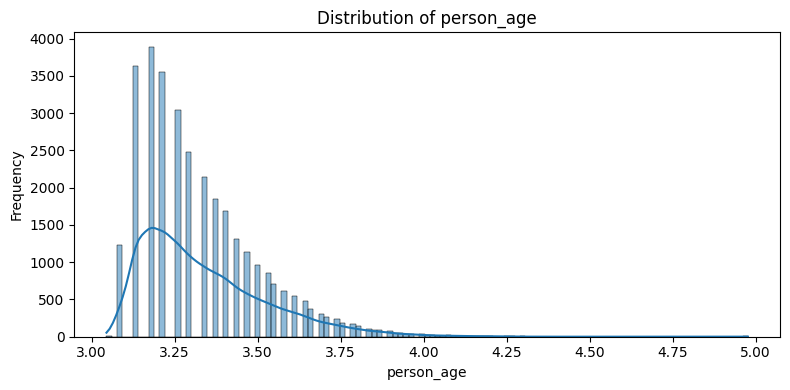

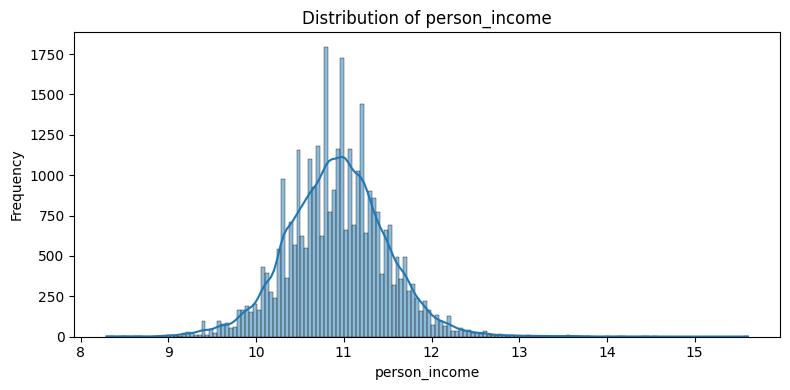

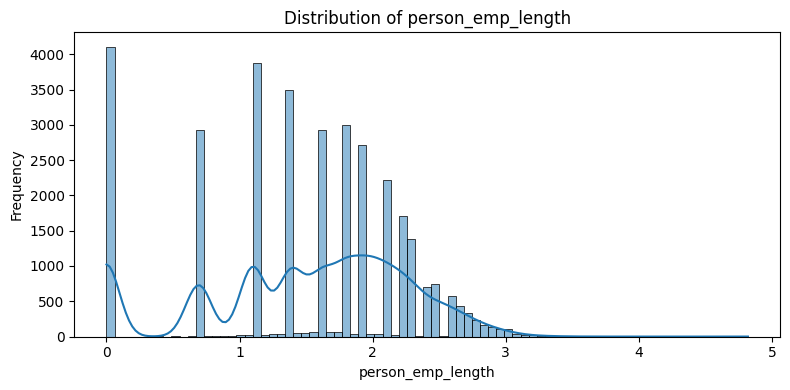

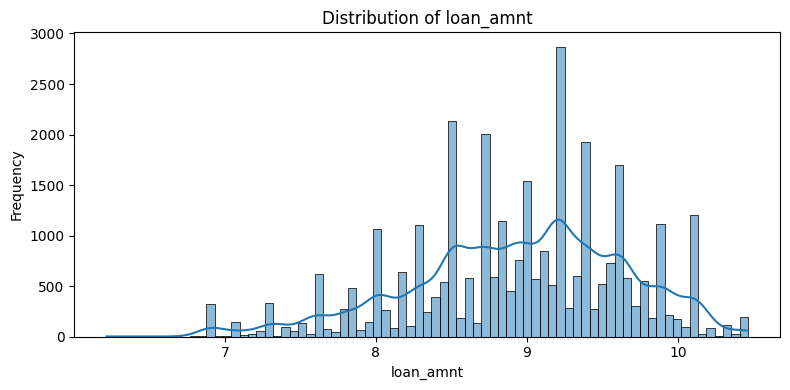

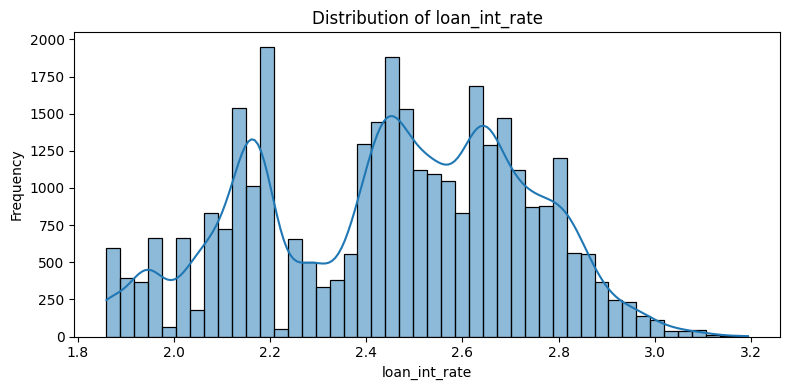

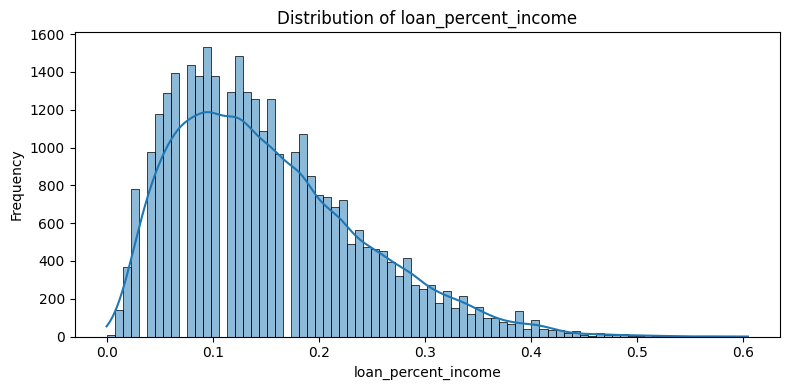

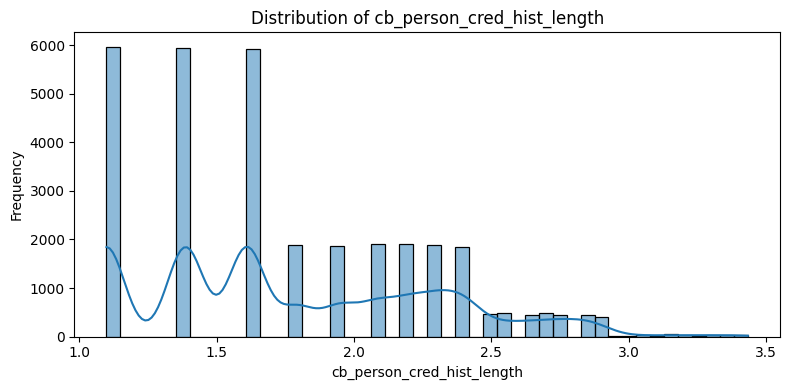

In [11]:
for name in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(transformation_df[name], kde=True)
    plt.title(f'Distribution of {name}')
    plt.xlabel(name)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [13]:
def smooth_log_transformed_outliers(df, columns, upper_percentile=0.99, lower_percentile=0.01):
    df_smooth = df.copy()

    for col in columns:
        p_upper = df[col].quantile(upper_percentile)
        p_lower = df[col].quantile(lower_percentile)
        print(f"column>>>{col} upper quantile val - {p_upper}")
        print(f"column>>>{col} lower quantile val - {p_lower}")
        def smooth_value(x):
            if x > p_upper:
                return p_upper + 0.1 * (x - p_upper)  # compress extreme values slightly
            elif x < p_lower:
                return p_lower - 0.1 * (p_lower - x)  # symmetric for lower tail
            else:
                return x
        
        df_smooth[col] = df[col].apply(smooth_value)
    
    return df_smooth


In [14]:
df_smoothed = smooth_log_transformed_outliers(transformation_df, numeric_columns)

column>>>person_age upper quantile val - 3.9318256327243257
column>>>person_age lower quantile val - 3.091042453358316
column>>>person_income upper quantile val - 12.324747041101583
column>>>person_income lower quantile val - 9.575052927597383
column>>>person_emp_length upper quantile val - 2.8903717578961645
column>>>person_emp_length lower quantile val - 0.0
column>>>loan_amnt upper quantile val - 10.30229722897745
column>>>loan_amnt lower quantile val - 6.90875477931522
column>>>loan_int_rate upper quantile val - 2.976549454137217
column>>>loan_int_rate lower quantile val - 1.8594181177018698
column>>>loan_percent_income upper quantile val - 0.4054651081081644
column>>>loan_percent_income lower quantile val - 0.019802627296179712
column>>>cb_person_cred_hist_length upper quantile val - 2.8903717578961645
column>>>cb_person_cred_hist_length lower quantile val - 1.0986122886681098


In [15]:
df_smoothed.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,3.135494,10.985310,RENT,3.083363,PERSONAL,D,10.318381,2.834389,1,0.411292,Y,1.386294
1,3.091042,9.534510,OWN,1.791759,EDUCATION,B,6.908755,2.496506,0,0.095310,N,1.098612
2,3.258097,9.534510,MORTGAGE,0.693147,MEDICAL,C,8.612685,2.629728,1,0.410026,N,1.386294
3,3.178054,11.089821,RENT,1.609438,MEDICAL,C,10.318381,2.786861,1,0.407445,N,1.098612
4,3.218876,10.904138,RENT,2.197225,MEDICAL,C,10.318381,2.725890,1,0.408744,Y,1.609438


In [20]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
df_scaled = df_smoothed.copy()

df_scaled[numeric_columns] = scaler.fit_transform(df_smoothed[numeric_columns])

In [21]:
joblib.dump(scaler,r'..\artifacts\models\scaler.pkl')

['..\\artifacts\\models\\scaler.pkl']